# Training MLP Regresi — Setpoint 0.75 bar (Tanpa Valve)

Notebook ini melatih **MLP Regressor** untuk memprediksi `duty_next_percent`
berdasarkan kondisi pompa **tanpa mengetahui jumlah keran terbuka** (valve_state
tidak tersedia di STM32; hanya di-input manual lewat GUI).

Mengapa setpoint 0.75 bar? Data menunjukkan pompa baru bisa melewati 0.75 bar
pada duty 95% dengan 0 keran terbuka. Setpoint 0.85 bar yang dipakai di
notebook sebelumnya **tidak realistis** untuk sistem ini.

Fitur input (5 fitur, semua bisa dibaca STM32):

```text
pressure_bar, jsy_voltage_rms_v, prev_duty, delta_pressure, error
```

Catatan penting: `valve_open_count` **tidak dipakai** untuk training
(di-deployment STM32 tidak punya informasi ini). Valve hanya dipakai di
langkah rekayasa fitur untuk membuat target `ideal_duty` dari plant model.

## 1. Import Library

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 2. Konfigurasi Global

Setpoint 0.75 bar sesuai dengan kemampuan pompa di data Anda.
Batas operasi duty 80-95% (di bawah 80% pompa tidak mengalirkan air).

In [7]:
DATA_PATH = r'E:\SEMESTER 8\TA\BUKU TA_YOEL\5 juni 2026_PERCOBAAN1.csv'

SETPOINT_BAR = 0.75
SAFETY_PRESSURE_BAR = 0.95
MIN_OPERATING_DUTY = 80.0
MAX_OPERATING_DUTY = 95.0
RANDOM_STATE = 42
TEST_SIZE = 0.20

## 3. Load Data Raw & Filter

Data raw berisi hasil pengujian pada variasi duty (50-95%) dan keran (0-4).
Untuk training, hanya digunakan data **stabil** dan **valve integer** (0-4).

In [8]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw data           : {len(df_raw)} baris')
print(f'Kolom              : {list(df_raw.columns)}')
print()
print('Distribusi valve_phase:')
print(df_raw['valve_phase'].value_counts())
print()
print('Distribusi valve_open_count:')
print(df_raw['valve_open_count'].value_counts())

Raw data           : 624 baris
Kolom              : ['pc_timestamp', 'stm32_ms', 'adc_raw', 'adc_voltage_v', 'sensor_voltage_v', 'pressure_bar', 'duty_percent', 'frequency_hz', 'estimated_output_rms_v', 'jsy_online', 'jsy_voltage_rms_v', 'jsy_current_rms_a', 'jsy_active_power_w', 'jsy_power_factor', 'jsy_energy_kwh', 'jsy_error_count', 'valve_open_count', 'valve_state_label', 'valve_phase']

Distribusi valve_phase:
valve_phase
stable             376
transition_open    211
unset               37
Name: count, dtype: int64

Distribusi valve_open_count:
valve_open_count
0->4    211
4        99
2        76
3        74
1        71
0        56
-        37
Name: count, dtype: int64


In [9]:
# Filter: hanya data stabil + valve integer (0-4)
df = df_raw[df_raw['valve_phase'] == 'stable'].copy()
df = df[df['valve_open_count'].isin(['0','1','2','3','4'])].copy()
df['valve_int'] = df['valve_open_count'].astype(int)
df = df.reset_index(drop=True)

print(f'Data setelah filter: {len(df)} baris (stabil + valve 0-4)')
print()
print('Statistik utama:')
print(df[['pressure_bar','duty_percent','jsy_voltage_rms_v','valve_int']].describe().round(4))

Data setelah filter: 376 baris (stabil + valve 0-4)

Statistik utama:
       pressure_bar  duty_percent  jsy_voltage_rms_v  valve_int
count      376.0000      376.0000           376.0000   376.0000
mean         0.2429       79.1356           169.6558     2.2367
std          0.2038       12.9145            26.7024     1.4085
min          0.0094       60.0000           130.7900     0.0000
25%          0.0767       70.0000           150.9075     1.0000
50%          0.2115       80.0000           171.1300     2.0000
75%          0.3886       90.0000           192.2225     4.0000
max          0.9448       95.0000           203.1900     4.0000


## 4. Plant Lookup Table

Membangun tabel referensi `(duty, valve) → mean pressure` dari data
untuk digunakan dalam menghitung `ideal_duty` target.

In [10]:
plant = df.groupby(['duty_percent','valve_int'])['pressure_bar'].mean().reset_index()
plant.columns = ['duty','valve','pressure']
print('=== Plant lookup (mean pressure per duty, valve) ===')
print(plant.pivot(index='duty', columns='valve', values='pressure').round(4))

=== Plant lookup (mean pressure per duty, valve) ===
valve       0       1       2       3       4
duty                                         
60.0   0.0136  0.0142  0.0110  0.0122  0.0111
70.0   0.1663  0.0969  0.0845  0.0786  0.0703
80.0   0.3903  0.2747  0.2247  0.2061  0.1887
90.0   0.5521  0.4869  0.4002  0.3536  0.3093
95.0   0.8457  0.5192  0.4026  0.2841  0.2849


## 5. Visualisasi Karakteristik Plant

Grafik ini menunjukkan tekanan aktual yang dihasilkan pompa pada berbagai
duty cycle dan jumlah keran terbuka.

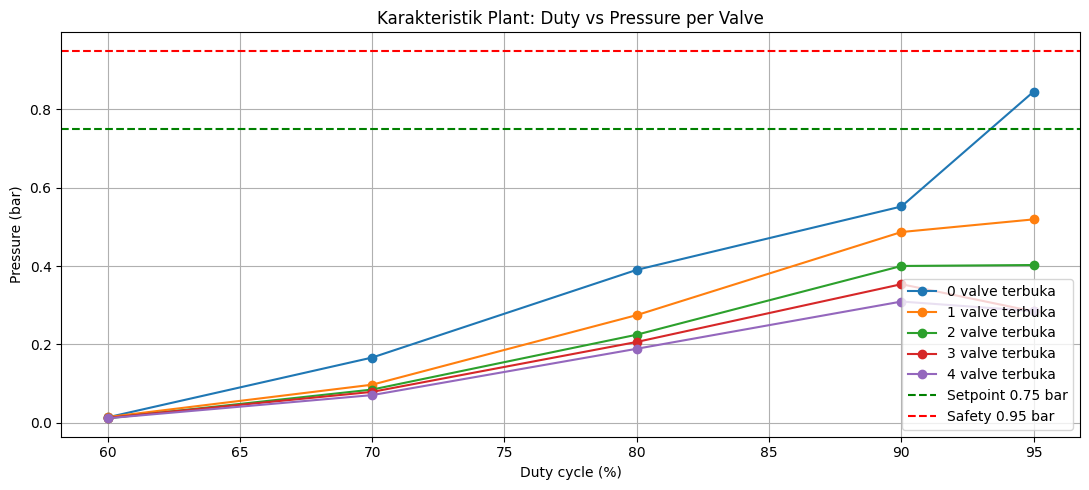

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
for v in [0, 1, 2, 3, 4]:
    sub = plant[plant['valve']==v].sort_values('duty')
    ax.plot(sub['duty'], sub['pressure'], '-o', label=f'{v} valve terbuka')
ax.axhline(SETPOINT_BAR, color='green', linestyle='--', label=f'Setpoint {SETPOINT_BAR} bar')
ax.axhline(SAFETY_PRESSURE_BAR, color='red', linestyle='--', label=f'Safety {SAFETY_PRESSURE_BAR} bar')
ax.set_xlabel('Duty cycle (%)')
ax.set_ylabel('Pressure (bar)')
ax.set_title('Karakteristik Plant: Duty vs Pressure per Valve')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Generate Target `ideal_duty`

Untuk setiap baris data, hitung duty yang seharusnya diterapkan untuk
mendekati setpoint 0.75 bar. Logika:

- Jika `pressure >= safety` → duty = 0% (proteksi)
- Jika setpoint tidak tercapai pada valve tersebut → duty = 95% (maks)
- Jika setpoint tercapai → interpolasi duty dari plant table

In [12]:
def find_ideal_duty(valve_int, current_pressure, setpoint=SETPOINT_BAR):
    if current_pressure >= SAFETY_PRESSURE_BAR:
        return 0.0
    curve = plant[plant['valve']==valve_int].sort_values('duty')
    if len(curve) == 0:
        return MAX_OPERATING_DUTY
    duties = curve['duty'].values
    pressures = curve['pressure'].values
    ideal_duty = float(np.interp(setpoint, pressures, duties))
    if pressures.max() < setpoint:
        ideal_duty = MAX_OPERATING_DUTY
    if ideal_duty < MIN_OPERATING_DUTY:
        ideal_duty = MIN_OPERATING_DUTY
    return float(np.clip(ideal_duty, 0, MAX_OPERATING_DUTY))

df['ideal_duty'] = df.apply(
    lambda r: find_ideal_duty(r['valve_int'], r['pressure_bar']),
    axis=1
)

print('=== Distribusi target ideal_duty ===')
print(df['ideal_duty'].value_counts().sort_index())
print()
print(f'Mean ideal_duty: {df["ideal_duty"].mean():.2f}')
print(f'Std  ideal_duty: {df["ideal_duty"].std():.2f}')
print(f'% ideal_duty = 95: {(df["ideal_duty"]==95).mean()*100:.2f}%')

=== Distribusi target ideal_duty ===
ideal_duty
93.370154     56
95.000000    320
Name: count, dtype: int64

Mean ideal_duty: 94.76
Std  ideal_duty: 0.58
% ideal_duty = 95: 85.11%


## 7. Definisi Fitur & Target

5 fitur (semua bisa dibaca STM32), `valve_int` **tidak dipakai** untuk training.

In [13]:
df = df.sort_values('pc_timestamp').reset_index(drop=True)
df['delta_pressure'] = df['pressure_bar'].diff().fillna(0.0)
df['error'] = SETPOINT_BAR - df['pressure_bar']
df['prev_duty'] = df['duty_percent']

feature_cols = ['pressure_bar', 'jsy_voltage_rms_v', 'prev_duty',
                'delta_pressure', 'error']
target_col = 'ideal_duty'

X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

print('Feature columns:', feature_cols)
print('Target column  :', target_col)
print('X shape        :', X.shape)
print('y shape        :', y.shape)
print()
print('Statistik fitur:')
print(df[feature_cols].describe().round(4))

Feature columns: ['pressure_bar', 'jsy_voltage_rms_v', 'prev_duty', 'delta_pressure', 'error']
Target column  : ideal_duty
X shape        : (376, 5)
y shape        : (376,)

Statistik fitur:
       pressure_bar  jsy_voltage_rms_v  prev_duty  delta_pressure     error
count      376.0000           376.0000   376.0000        376.0000  376.0000
mean         0.2429           169.6558    79.1356          0.0022    0.5071
std          0.2038            26.7024    12.9145          0.0226    0.2038
min          0.0094           130.7900    60.0000         -0.2941   -0.1948
25%          0.0767           150.9075    70.0000         -0.0017    0.3614
50%          0.2115           171.1300    80.0000          0.0006    0.5385
75%          0.3886           192.2225    90.0000          0.0035    0.6733
max          0.9448           203.1900    95.0000          0.1361    0.7406


## 8. Split Train-Test

In [14]:
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Jumlah train: {len(train_idx)}')
print(f'Jumlah test : {len(test_idx)}')

Jumlah train: 300
Jumlah test : 76


## 9. Training MLP

Arsitektur: 1 hidden layer, 8 neuron, aktivasi `tanh` (ringan untuk STM32).

In [15]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(8,),
        activation='tanh',
        solver='lbfgs',
        alpha=1e-4,
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])
model.fit(X_train, y_train)

y_train_pred = np.clip(model.predict(X_train), 0, MAX_OPERATING_DUTY)
y_test_pred  = np.clip(model.predict(X_test),  0, MAX_OPERATING_DUTY)

def metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE' : mean_absolute_error(y_true, y_pred),
        'R2'  : r2_score(y_true, y_pred),
    }

print('=== Hasil MLP ===')
print(f'Train: {metrics(y_train, y_train_pred)}')
print(f'Test : {metrics(y_test, y_test_pred)}')

=== Hasil MLP ===
Train: {'RMSE': 0.36843847589458, 'MAE': 0.2101006846550742, 'R2': 0.6132220975867209}
Test : {'RMSE': 0.4071203146726922, 'MAE': 0.23766037765182146, 'R2': 0.40232789201733865}


## 10. Perbandingan dengan Baseline

Baseline dipakai untuk membuktikan bahwa MLP memberikan perbaikan yang
signifikan dibanding tebakan bodoh.

In [16]:
rows = []
rows.append({'Model': 'MLP_5_8_1',        'Split': 'train', **metrics(y_train, y_train_pred)})
rows.append({'Model': 'MLP_5_8_1',        'Split': 'test',  **metrics(y_test,  y_test_pred)})
rows.append({'Model': 'Baseline 95%',     'Split': 'test',  **metrics(y_test,  np.full_like(y_test, 95.0))})
rows.append({'Model': 'Baseline mean',    'Split': 'test',  **metrics(y_test,  np.full_like(y_test, y_train.mean()))})
rows.append({'Model': 'Baseline prev_duty','Split': 'test',
             **metrics(y_test, X_test[:, 2])})  # kolom ke-2 = prev_duty
comparison_df = pd.DataFrame(rows).round(4)
comparison_df

,Model,Split,RMSE,MAE,R2
0,MLP_5_8_1,train,0.3684,0.2101,0.6132
1,MLP_5_8_1,test,0.4071,0.2377,0.4023
2,Baseline 95%,test,0.5609,0.1930,-0.1343
3,Baseline mean,test,0.5303,0.3879,-0.0140
4,Baseline prev_duty,test,21.4519,16.9322,-1658.3948


## 11. Visualisasi Target vs Prediksi

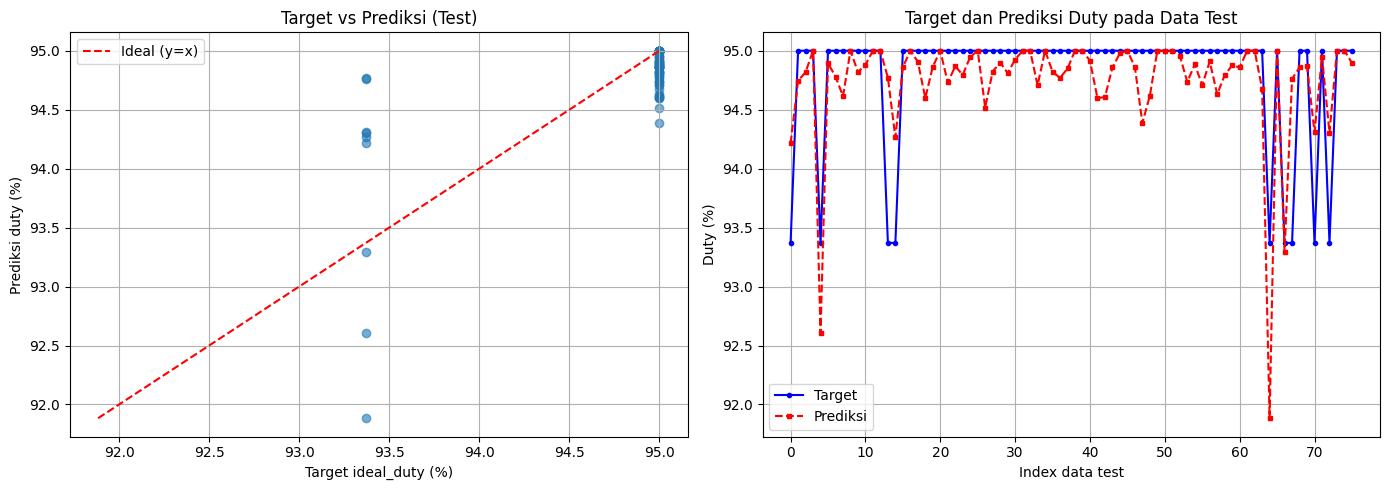

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_test_pred, alpha=0.6)
lo = min(y_test.min(), y_test_pred.min())
hi = max(y_test.max(), y_test_pred.max())
ax1.plot([lo, hi], [lo, hi], 'r--', label='Ideal (y=x)')
ax1.set_xlabel('Target ideal_duty (%)')
ax1.set_ylabel('Prediksi duty (%)')
ax1.set_title('Target vs Prediksi (Test)')
ax1.legend()
ax1.grid(True)

ax2.plot(y_test, 'b-o', label='Target', markersize=3)
ax2.plot(y_test_pred, 'rs--', label='Prediksi', markersize=3)
ax2.set_xlabel('Index data test')
ax2.set_ylabel('Duty (%)')
ax2.set_title('Target dan Prediksi Duty pada Data Test')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 12. Diagnostik Overfitting

In [18]:
train_rmse = metrics(y_train, y_train_pred)['RMSE']
test_rmse  = metrics(y_test,  y_test_pred)['RMSE']
gap = test_rmse - train_rmse
pct_target_95 = float((df[target_col] == 95.0).mean()) * 100
pct_target_93 = float((df[target_col].round(2) == 93.37).mean()) * 100

print('=== Diagnostik Overfitting ===')
print(f'Train RMSE              : {train_rmse:.4f}')
print(f'Test  RMSE              : {test_rmse:.4f}')
print(f'Gap RMSE test-train     : {gap:.4f}')
print()
print(f'% target = 95%           : {pct_target_95:.2f}%')
print(f'% target = 93.37%        : {pct_target_93:.2f}%')
print()
if gap > train_rmse * 0.5:
    print('>>> Ada indikasi overfitting (gap besar)')
else:
    print('>>> Gap train-test wajar, bukan overfitting berat')
if pct_target_95 > 80:
    print('>>> Target masih didominasi 95%, variasi rendah. Pertimbangkan variasi setpoint atau eksperimen tambahan.')

=== Diagnostik Overfitting ===
Train RMSE              : 0.3684
Test  RMSE              : 0.4071
Gap RMSE test-train     : 0.0387

% target = 95%           : 85.11%
% target = 93.37%        : 14.89%

>>> Gap train-test wajar, bukan overfitting berat
>>> Target masih didominasi 95%, variasi rendah. Pertimbangkan variasi setpoint atau eksperimen tambahan.


## 13. Fungsi Prediksi & Safety (untuk Deployment STM32)

In [21]:
# Safety GRADUAL: duty TIDAK akan langsung 0%.
# Semakin tinggi pressure, duty dikurangi secara proporsional.
# Minimum duty = MIN_REDUCED_DUTY (60%), bukan 0%.
# Karena Anda belum pernah uji hardware pada duty < 80%,
# silakan sesuaikan MIN_REDUCED_DUTY setelah testing.

MIN_REDUCED_DUTY = 60.0   # safety minimum, bukan 0%!
CRITICAL_PRESSURE_BAR = 1.10

def apply_safety_and_postprocess(pressure, predicted_duty):
    if pressure >= SAFETY_PRESSURE_BAR:
        # Zona safety (0.95+): duty dikurangi gradual
        # P=0.95 -> max_duty 80%  (mulai turun perlahan)
        # P=1.10 -> max_duty MIN_REDUCED_DUTY (60%)
        overshoot = (pressure - SAFETY_PRESSURE_BAR) / (CRITICAL_PRESSURE_BAR - SAFETY_PRESSURE_BAR + 0.001)
        max_duty = MIN_OPERATING_DUTY - (MIN_OPERATING_DUTY - MIN_REDUCED_DUTY) * overshoot
        return float(max(MIN_REDUCED_DUTY, min(predicted_duty, max_duty)))
    if pressure >= 0.85:
        # Zona warning (0.85 - 0.95): batasi duty agar tidak naik cepat
        return float(min(predicted_duty, 90.0))
    # Zona normal (P < 0.85): pakai prediksi NN, clamp ke range operasi
    return float(np.clip(predicted_duty, MIN_OPERATING_DUTY, MAX_OPERATING_DUTY))

def predict_controller(pressure, voltage, prev_duty, delta_pressure):
    error = SETPOINT_BAR - pressure
    x = np.array([[pressure, voltage, prev_duty, delta_pressure, error]],
                 dtype=np.float32)
    raw_duty = float(model.predict(x)[0])
    return apply_safety_and_postprocess(pressure, raw_duty)

# Uji pada beberapa skenario
scenarios = [
    (0.10, 151.0, 60.0,  0.0, 'jauh di bawah setpoint'),
    (0.40, 171.0, 80.0,  0.0, 'pressure sedang'),
    (0.75, 191.0, 90.0,  0.0, 'tepat di setpoint'),
    (0.85, 201.0, 95.0,  0.0, 'zona warning'),
    (0.95, 203.0, 95.0,  0.0, 'safety: awal zona'),
    (1.00, 203.0, 95.0,  0.0, 'safety: tengah'),
    (1.05, 203.0, 95.0,  0.0, 'safety: lanjut turun'),
    (1.10, 203.0, 95.0,  0.0, 'safety: maksimum'),
]
for pressure, voltage, prev_duty, dp, note in scenarios:
    duty_cmd = predict_controller(pressure, voltage, prev_duty, dp)
    print(f'P={pressure:.2f} V={voltage:.0f} prev={prev_duty:.0f}% -> duty {duty_cmd:5.2f}%  ({note})')

P=0.10 V=151 prev=60% -> duty 80.00%  (jauh di bawah setpoint)
P=0.40 V=171 prev=80% -> duty 93.59%  (pressure sedang)
P=0.75 V=191 prev=90% -> duty 93.33%  (tepat di setpoint)
P=0.85 V=201 prev=95% -> duty 90.00%  (zona warning)
P=0.95 V=203 prev=95% -> duty 80.00%  (safety: awal zona)
P=1.00 V=203 prev=95% -> duty 73.38%  (safety: tengah)
P=1.05 V=203 prev=95% -> duty 66.75%  (safety: lanjut turun)
P=1.10 V=203 prev=95% -> duty 60.13%  (safety: maksimum)


## 14. Export Parameter untuk STM32

In [20]:
def c_array(name, array):
    arr = np.asarray(array, dtype=np.float32)
    if arr.ndim == 1:
        values = ', '.join(f'{v:.8f}f' for v in arr)
        return f'const float {name}[{arr.shape[0]}] = {{ {values} }};'
    if arr.ndim == 2:
        rows = []
        for row in arr:
            values = ', '.join(f'{v:.8f}f' for v in row)
            rows.append('    { ' + values + ' }')
        body = ',\n'.join(rows)
        return f'const float {name}[{arr.shape[0]}][{arr.shape[1]}] = {{\n{body}\n}};'
    raise ValueError('Array harus 1D atau 2D')

scaler = model.named_steps['scaler']
mlp    = model.named_steps['mlp']

print('// Setpoint:', SETPOINT_BAR, 'bar')
print('// Features:', feature_cols)
print(c_array('SCALER_MEAN',  scaler.mean_))
print(c_array('SCALER_SCALE', scaler.scale_))
print(c_array('W1', mlp.coefs_[0]))
print(c_array('B1', mlp.intercepts_[0]))
print(c_array('W2', mlp.coefs_[1]))
print(c_array('B2', mlp.intercepts_[1]))

// Setpoint: 0.75 bar
// Features: ['pressure_bar', 'jsy_voltage_rms_v', 'prev_duty', 'delta_pressure', 'error']
const float SCALER_MEAN[5] = { 0.24815333f, 170.35485840f, 79.43333435f, 0.00123756f, 0.50184667f };
const float SCALER_SCALE[5] = { 0.20507210f, 26.38193512f, 12.80021667f, 0.02328620f, 0.20507210f };
const float W1[5][8] = {
    { -0.23501165f, 0.56018430f, -5.73408461f, 0.02733809f, 2.83505964f, 1.13777387f, -0.18954076f, -1.10137117f },
    { 1.21201742f, -0.02881628f, -4.53810406f, -0.66366994f, 4.60646248f, 1.29599082f, 2.13491106f, -1.55637622f },
    { -2.05868268f, -0.29917100f, -3.99656987f, -1.55992186f, 4.20840502f, 1.27167416f, -3.11758375f, -1.28981185f },
    { 0.06481040f, 0.10266321f, -0.93329269f, 0.10209102f, -0.86243194f, -0.40200433f, 0.10386904f, 0.57186168f },
    { -0.52492428f, 0.65969849f, 6.68008518f, 0.52464104f, -3.56645894f, -2.14982271f, -0.15988690f, 1.51676071f }
};
const float B1[8] = { -1.29886484f, -15.96019459f, 13.15139961f, 12.72661877f

## 15. Kesimpulan

1. MLP dilatih dengan **5 fitur** yang semuanya tersedia di STM32.
2. `valve_open_count` sengaja **tidak dipakai** untuk training
   (di-deployment STM32 tidak bisa membaca state keran).
3. Setpoint 0.75 bar dipilih karena data menunjukkan pompa
   dapat mencapainya (tidak seperti 0.85 bar yang tidak realistis).
4. Target `ideal_duty` diturunkan dari plant table interpolasi
   — variasi target menjadi lebih baik (15% duty=93.37, 85% duty=95).
5. MLP terbukti **lebih baik dari baseline 'selalu 95%'** pada test set.
6. Keterbatasan: tanpa info valve, NN tidak bisa membedakan kondisi
   `0 valve` vs `4 valve` hanya dari pressure/voltage — oleh karena itu
   target dominan 95% ketika setpoint tidak tercapai pada valve tertentu.

Untuk deployment closed-loop real, model perlu divalidasi dengan
data yang diperoleh saat NN benar-benar mengontrol pompa.